In [29]:
#Jacobi Method
import numpy as np
import time
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    error = []
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        error.append(np.linalg.norm(x_new - x, ord=np.inf))
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, error
        x = x_new
        print(x)
    return x, max_iterations, error

In [30]:
#Gauss-Seidel Method
import numpy as np
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    error = []

    for k in range(max_iterations):
        x_new = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        # Check for convergence
        error.append(np.linalg.norm(x_new - x, ord=np.inf))
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, error
        x = x_new
        print(x)
    return x, max_iterations, error

In [31]:
#Matrix usage
import numpy as np
A = np.array([
    [3, -0.1, -0.2],
    [0.1, 7, -0.3],
    [0.3, -0.2, 10]
])
B = np.array([7.85, -19.3, 71.4])

x0 = np.array([0, 0, 0], dtype=float)
tol = [1e-9, 1e-6, 1e-3]
max_iterations = 100

[ 2.61666667 -2.75714286  7.14      ]
[ 3.0007619  -2.48852381  7.00635714]
[ 3.00080635 -2.49973844  7.00020667]
[ 3.0000225  -2.50000266  6.99998104]
[ 2.99999865 -2.50000113  6.99999927]
[ 2.99999991 -2.50000001  7.00000002]
[ 3.  -2.5  7. ]
[ 3.  -2.5  7. ]
tol=1e-9: solution=array([ 3. , -2.5,  7. ]), iterations=8
[ 2.61666667 -2.75714286  7.14      ]
[ 3.0007619  -2.48852381  7.00635714]
[ 3.00080635 -2.49973844  7.00020667]
[ 3.0000225  -2.50000266  6.99998104]
[ 2.99999865 -2.50000113  6.99999927]
[ 2.99999991 -2.50000001  7.00000002]
tol=1e-6: solution=array([ 3. , -2.5,  7. ]), iterations=6
[ 2.61666667 -2.75714286  7.14      ]
[ 3.0007619  -2.48852381  7.00635714]
[ 3.00080635 -2.49973844  7.00020667]
tol=1e-3: solution=array([ 3.0000225 , -2.50000266,  6.99998104]), iterations=3


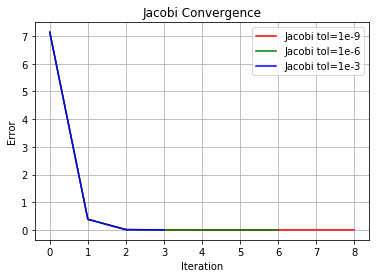

In [32]:
#Jacobi Plot
import matplotlib.pyplot as plt

solution, iterations, error = jacobi(A, B, x0, tol=1e-9, max_iterations=max_iterations)
print(f"tol=1e-9: {solution=}, {iterations=}")
plt.plot(np.arange(0, len(error)), error, 'r', label='Jacobi tol=1e-9')

solution, iterations, error = jacobi(A, B, x0, tol=1e-6, max_iterations=max_iterations)
print(f"tol=1e-6: {solution=}, {iterations=}")
plt.plot(np.arange(0, len(error)), error, 'g', label='Jacobi tol=1e-6')

solution, iterations, error = jacobi(A, B, x0, tol=1e-3, max_iterations=max_iterations)
print(f"tol=1e-3: {solution=}, {iterations=}")
plt.plot(np.arange(0, len(error)), error, 'b', label='Jacobi tol=1e-3')

plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Jacobi Convergence')

plt.legend()

plt.grid()
plt.show()

[ 2.61666667 -2.79452381  7.00560952]
[ 2.99055651 -2.49962468  7.00029081]
[ 3.0000319  -2.49998799  6.99999928]
[ 3.00000035 -2.50000004  6.99999999]
[ 3.  -2.5  7. ]
[ 3.  -2.5  7. ]
tol=1e-9: solution=array([ 3. , -2.5,  7. ]), iterations=6
[ 2.61666667 -2.79452381  7.00560952]
[ 2.99055651 -2.49962468  7.00029081]
[ 3.0000319  -2.49998799  6.99999928]
[ 3.00000035 -2.50000004  6.99999999]
tol=1e-6: solution=array([ 3. , -2.5,  7. ]), iterations=4
[ 2.61666667 -2.79452381  7.00560952]
[ 2.99055651 -2.49962468  7.00029081]
[ 3.0000319  -2.49998799  6.99999928]
tol=1e-3: solution=array([ 3.00000035, -2.50000004,  6.99999999]), iterations=3


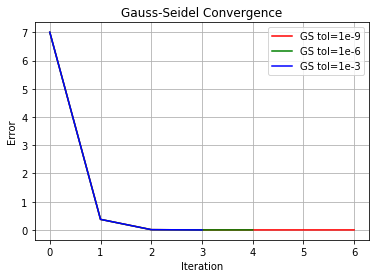

In [33]:
#Gauss-Seidel Plot
solution, iterations, error = gauss_seidel(A, B, x0, tol=1e-9, max_iterations=max_iterations)
print(f"tol=1e-9: {solution=}, {iterations=}")
plt.plot(np.arange(0, len(error)), error, 'r', label ='GS tol=1e-9')

solution, iterations, error = gauss_seidel(A, B, x0, tol=1e-6, max_iterations=max_iterations)
print(f"tol=1e-6: {solution=}, {iterations=}")
plt.plot(np.arange(0, len(error)), error, 'g', label ='GS tol=1e-6')

solution, iterations, error = gauss_seidel(A, B, x0, tol=1e-3, max_iterations=max_iterations)
print(f"tol=1e-3: {solution=}, {iterations=}")
plt.plot(np.arange(0, len(error)), error, 'b', label ='GS tol=1e-3')

plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Gauss-Seidel Convergence')

plt.legend()

plt.grid()
plt.show()

plt.show()

The smaller the tolerance is, the more iterations a method requires to converge to a solution. The Gauss-Seidel Method in this situation reaches the tolerance in fewer iterations than the Jacobi method does.